LABORATORIO 2:
HECHO POR: CAROLINA CHINCHILLA & WILLIAM POLLOCK (GRUPO 33)

In [ ]:
#0: CARGA DE DATOS EN BASE AL LABORATORIO 1
#------------------------------------------
import pandas as pd

train = pd.read_csv("./data/Datos Lab 1.csv")
test = pd.read_csv("./data/Datos Test Lab 1.csv", sep=";")
dicc = pd.read_excel("./data/DiccPacientes.xlsx")

#para ver si funciona bien
display(dicc.head())
print(train.shape, test.shape)

import numpy as np

print("Duplicados:", train.duplicated().sum())
na = (train.isna().mean()*100).sort_values(ascending=False)
display(na.head(10))

display(train.describe(include="all"))

cat_cols = ["Sex", "Smoking Status", "Diabetes Status", "Physical Activity Level", "Family History of CVD", "Blood Pressure Category", "CVD Risk Level"]
for c in cat_cols:
    print("\n", c)
    display(train[c].astype(str).str.strip().str.upper().value_counts(dropna=False))

train2 = train.drop_duplicates().copy()
train2 = train2[train2["CVD Risk Score"].notna()].copy()

from sklearn.model_selection import train_test_split

X = train2.drop(columns=["CVD Risk Score", "CVD Risk Level"], errors="ignore")
y = train2["CVD Risk Score"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

drop_comun = ["Patient ID", "Date of Service", "Blood Pressure (mmHg)"]

X_temp = X.drop(columns=drop_comun, errors="ignore")
num_cols = X_temp.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_temp.select_dtypes(exclude=["number"]).columns.tolist()

print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso


(1639, 24) (194, 22)
Duplicados: 151


Diastolic BP                    5.186089
HDL (mg/dL)                     5.003051
Waist-to-Height Ratio           4.636974
Weight (kg)                     4.453935
Height (cm)                     4.148871
Age                             4.148871
Total Cholesterol (mg/dL)       4.148871
Height (m)                      3.721782
Abdominal Circumference (cm)    3.721782
Systolic BP                     3.721782
dtype: float64

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
count,1639,1639,1639,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1639,1571.000000,...,1639,1639,1571.000000,1563.000000,1578.000000,1554.000000,1639,1582.000000,1610.000000,1639
unique,1376,1274,2,NaN,NaN,NaN,NaN,NaN,1152,NaN,...,3,2,NaN,NaN,NaN,NaN,4,NaN,NaN,3
top,THSJ8564,09-20-2023,M,NaN,NaN,NaN,NaN,NaN,124/72,NaN,...,High,N,NaN,NaN,NaN,NaN,Hypertension Stage 2,NaN,NaN,HIGH
freq,3,6,821,NaN,NaN,NaN,NaN,NaN,6,NaN,...,582,820,NaN,NaN,NaN,NaN,680,NaN,NaN,793
mean,NaN,NaN,NaN,46.803186,85.666006,1.757439,28.424744,91.538861,NaN,199.043673,...,NaN,NaN,175.770082,0.522440,125.632637,82.887536,NaN,113.235896,18.227281,NaN
std,NaN,NaN,NaN,13.039479,21.712504,0.118012,7.309275,13.427985,NaN,59.388670,...,NaN,NaN,11.695880,0.085692,22.577463,15.503625,NaN,61.435291,10.767666,NaN
min,NaN,NaN,NaN,6.134000,13.261000,1.371000,4.317000,49.542000,NaN,-1.256000,...,NaN,NaN,136.498000,0.250000,49.914000,31.720000,NaN,-92.055000,-20.057000,NaN
25%,NaN,NaN,NaN,37.000000,67.100000,1.666500,22.600000,79.700000,NaN,150.000000,...,NaN,NaN,167.000000,0.453000,108.000000,71.000000,NaN,62.000000,15.150000,NaN
50%,NaN,NaN,NaN,46.000000,86.314000,1.760000,28.000000,91.200000,NaN,199.000000,...,NaN,NaN,176.000000,0.519000,125.000000,82.000000,NaN,112.000000,16.967000,NaN
75%,NaN,NaN,NaN,55.000000,104.801500,1.850000,33.963000,102.267250,NaN,250.000000,...,NaN,NaN,185.000000,0.582000,141.000000,93.000000,NaN,159.000000,18.900000,NaN



 Sex


...


 Blood Pressure Category


Blood Pressure Category
HYPERTENSION STAGE 2    680
HYPERTENSION STAGE 1    527
NORMAL                  321
ELEVATED                111
Name: count, dtype: int64


 CVD Risk Level


CVD Risk Level
HIGH            793
INTERMEDIARY    616
LOW             230
Name: count, dtype: int64

Columnas numéricas: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Columnas categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


In [6]:
#1: CONSTRUCCIÓN DE MODELO DE REGRESIÓN POLINOMIAL
#--------------------------------------------------


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# MODELO POLINOMIAL GRADO 2

numeric_transform_g2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
])

categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor_g2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_g2, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)

pipeline_poly_g2 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_g2),
    ("modelo", LinearRegression()),
])


pipeline_poly_g2.fit(X_train, y_train)
modelo = pipeline_poly_g2.named_steps["modelo"]
print("Número de coeficientes:", len(modelo.coef_))


y_train_pred = pipeline_poly_g2.predict(X_train)

print("---- Grado 2 - Entrenamiento ----")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))


y_val_pred = pipeline_poly_g2.predict(X_val)

print("---- Grado 2 - Validación ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))





#MODELO POLINOMIAL GRADO 3
numeric_transform_g3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=3, include_bias=False)),
])


preprocessor_g3 = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_g3, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)

pipeline_poly_g3 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_g3),
    ("modelo", LinearRegression()),
])

pipeline_poly_g3.fit(X_train, y_train)

modelo = pipeline_poly_g3.named_steps["modelo"]
print("Número de coeficientes:", len(modelo.coef_))

y_train_pred = pipeline_poly_g3.predict(X_train)

print("---- Grado 3 - Entrenamiento ----")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))


y_val_pred = pipeline_poly_g3.predict(X_val)

print("---- Grado 3 - Validación ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))



#GRID SEARCH PARA POLINOMIAL GRADO 2 Y 3

numeric_transform_polinomial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False)),
])


preprocessor_polinomial = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_polinomial, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)



pipeline_regresion_polinomial = Pipeline(steps=[
    ("preprocesamiento", preprocessor_polinomial),
    ("modelo", LinearRegression()),
])



grid = GridSearchCV(
    pipeline_regresion_polinomial,
    param_grid={
        "preprocesamiento__num__polynomial__degree": [1, 2, 3]
    },
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)


grid.fit(X_train, y_train)

print("Mejor grado:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("---- Resultados en Validación ----")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)




results = pd.DataFrame(grid.cv_results_)

results[[
    "param_preprocesamiento__num__polynomial__degree",
    "mean_train_score",
    "mean_test_score"
]]

Número de coeficientes: 113
---- Grado 2 - Entrenamiento ----
RMSE: 10.106778280205551
MAE: 4.230956856940249
R2: 0.13708380205462478
---- Grado 2 - Validación ----
RMSE: 11.643554490152052
MAE: 4.947854510063027
R2: -0.1646532657285258
Número de coeficientes: 568
---- Grado 3 - Entrenamiento ----
RMSE: 7.199766232667506
MAE: 3.9101293094699625
R2: 0.5620949678567047
---- Grado 3 - Validación ----
RMSE: 1772.326404698967
MAE: 251.22249017468894
R2: -26983.408607677393
Mejor grado: {'preprocesamiento__num__polynomial__degree': 1}
Mejor RMSE (CV): 10.174948959755413
---- Resultados en Validación ----
RMSE: 10.641544117034249
MAE: 3.7052360940781965
R2: 0.02717485248345497


,param_preprocesamiento__num__polynomial__degree,mean_train_score,mean_test_score
0,1,-10.520320,-10.174949
1,2,-10.045238,-10.979553
2,3,-6.745521,-4115.357970


Dados los datos se puede ver que el mejor grado de ajsute es el 1, sin embargo, si se analiza detenidamente cada  dato se observa que los de grado 2 y 3 tiene un sobreajuste dado que al comparar los valores de RMSE, MAE Y R2 en el entrenamiento y validación lso cambios son muy d´rasticos por ejemplo en grado 3 el R2 en entrenamiento es0.56 pero en validación es -26983, es decir, que el modelo se aprendió los patrones de los datos sin generalizar.

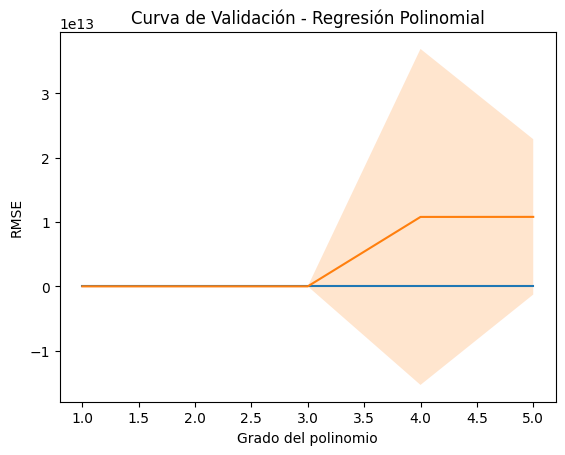

In [ ]:
#1.5: CURVA DE VALIDACIÓN
#-----------------------

import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

param_range = [1, 2, 3, 4, 5]
train_scores, val_scores = validation_curve(
    pipeline_regresion_polinomial,
    X_train,
    y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=param_range,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)



train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)



plt.figure()

plt.plot(param_range, train_mean)
plt.plot(param_range, val_mean)

plt.fill_between(param_range,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(param_range,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Curva de Validación")

plt.show()


De acuerdo a la grádica, el grado óptimo es 1 o 2. A partir del grado 3 comienza a existir sobreajuste, evidenciado por la brecha train/val y la varianza descontrolada, se podría ver que el modelo polinomial de alto grado sufre de multicolinealidad

In [10]:
#2: CONSTRUCCIÓN DE MODELO DE REGRESIÓN LINEAL REGULARIZADA
#----------------------------------------------------------


#base

from sklearn.linear_model import LinearRegression, Ridge, Lasso

numeric_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transform, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)



#modelo sin regularización
pipeline_lr = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", LinearRegression()),
])

pipeline_lr.fit(X_train, y_train)

y_val_pred = pipeline_lr.predict(X_val)

print("---- Regresión Lineal ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))



#RIDGE

pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", Ridge()),
])


param_grid_ridge = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 100],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()]
}

grid_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Mejor alpha Ridge:", grid_ridge.best_params_)
print("Mejor RMSE Ridge:", -grid_ridge.best_score_)



#LASSO
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", Lasso(max_iter=10000)),
])


param_grid_lasso = {
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 10],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()]
}

grid_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Mejor alpha Lasso:", grid_lasso.best_params_)
print("Mejor RMSE Lasso:", -grid_lasso.best_score_)




#Comparación
modelos = {
    "Lineal": pipeline_lr,
    "Ridge": grid_ridge.best_estimator_,
    "Lasso": grid_lasso.best_estimator_,
}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_val)
    print(f"\n---- {nombre} ----")
    print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
    print("MAE:", mean_absolute_error(y_val, y_pred))
    print("R2:", r2_score(y_val, y_pred))




#COEFICIENTES DE LOS MODELOS

#RIDGE
ridge_model = grid_ridge.best_estimator_.named_steps["modelo"]
print("Coeficientes Ridge:")
print(ridge_model.coef_)


#LASSO
lasso_model = grid_lasso.best_estimator_.named_steps["modelo"]
coef_lasso = lasso_model.coef_

print("Coeficientes Lasso:")
print(coef_lasso)

print("Cantidad de coeficientes en cero:", np.sum(coef_lasso == 0))

---- Regresión Lineal ----
RMSE: 10.641544117034249
MAE: 3.7052360940781965
R2: 0.02717485248345497
Mejor alpha Ridge: {'modelo__alpha': 100, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE Ridge: 10.115785595952916
Mejor alpha Lasso: {'modelo__alpha': 0.1, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE Lasso: 10.091292872255835

---- Lineal ----
RMSE: 10.641544117034249
MAE: 3.7052360940781965
R2: 0.02717485248345497

---- Ridge ----
RMSE: 10.618103742456894
MAE: 3.5382717006837243
R2: 0.03145586111033405

---- Lasso ----
RMSE: 10.56858076450122
MAE: 3.6706633599414182
R2: 0.040469398000891665
Coeficientes Ridge:
[-0.53958124 -0.42521789 -0.04044717  1.4488425  -0.02250119  0.46179435
 -0.18165934  0.09828583  0.0719513  -0.15435133  0.76999259  0.01103126
 -0.0724591  -0.16382013  0.38363031  1.89329226 -0.67893896  0.46405613
 -0.95565145  0.33685284  0.29204727 -1.42508671]
Coeficientes Lasso:
[-0.         -0.         -0.          4.28468654 -0.          

La regularización mejora un poco el desempeño respecto al modelo lineal base. Lasso obtiene el mejor RMSE (10.57) y el mayor R² (0.040), seguido de Ridge (RMSE 10.62). Sin embargo, las mejoras son pequeñas, lo que sugiere que hay un problema con los datos que la regularización no puede resolver completamente.
Ridge penaliza con L2: donde encoge todos los coeficientes hacia cero pero ninguno llega exactamente a cero. Los 22 coeficientes permanecen activos, con magnitudes reducidas. E
 En cambio, Lasso penaliza con L1: aca se ve como llevó 15 de 22 coeficientes a cero, manteniendo solo 7 variabls, lo que implcai que mejora la interpretabildiad

In [ ]:
#3: CONSTRUCCIÓN DE MODELO DE REGRESIÓN POLINOMIAL REGULARIZADA
#-------------------------------------------------------------



numeric_transform_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  
    ("polynomial", PolynomialFeatures(include_bias=False)),
])



categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])


preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_poly, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)


#RIDGE
pipeline_poly_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor_poly),
    ("modelo", Ridge()),
])


param_grid = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
}



grid_poly_ridge = GridSearchCV(
    pipeline_poly_ridge,
    param_grid=param_grid,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

grid_poly_ridge.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_poly_ridge.best_params_)

print("Mejor RMSE CV:")
print(-grid_poly_ridge.best_score_)


best_model = grid_poly_ridge.best_estimator_

y_val_pred = best_model.predict(X_val)

print("---- Modelo Polinomial Regularizado ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))



results = pd.DataFrame(grid_poly_ridge.cv_results_)

results[[
    "param_preprocesamiento__num__polynomial__degree",
    "param_modelo__alpha",
    "mean_train_score",
    "mean_test_score"
]].sort_values("mean_test_score", ascending=False)



Mejores hiperparámetros:
{'modelo__alpha': 100, 'preprocesamiento__num__polynomial__degree': 4, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE CV:
10.09566331209147
---- Modelo Polinomial Regularizado ----
RMSE: 10.62599679914734
MAE: 3.5399680721780746
R2: 0.03001537505286367


,param_preprocesamiento__num__polynomial__degree,param_modelo__alpha,mean_train_score,mean_test_score
39,4,100.00,-10.504504,-10.095663
37,3,100.00,-10.546390,-10.096174
35,2,100.00,-10.584575,-10.101468
32,1,100.00,-10.543027,-10.115786
33,1,100.00,-10.642747,-10.128068
25,1,10.00,-10.543763,-10.129088
27,2,10.00,-10.489195,-10.133870
29,3,10.00,-10.378534,-10.137457
24,1,10.00,-10.521325,-10.160270
17,1,1.00,-10.521141,-10.162620


La regularización sí mejoró el sobreajuste, donde en este caso se observó que el grado 4 tiende a tener mejor resultado. Sin embargo, el R2 sigue teniendo problemas ya que está muy bajo.

In [13]:
#4: SELECCIÓN DEL MEJOR MODELO
#-----------------------------


print("RMSE promedio:", -grid.best_score_)
print("Desviación estándar:", 
      grid.cv_results_["std_test_score"][grid.best_index_])


resultados = pd.DataFrame({
    "Modelo": [
        "Polinomial",
        "Ridge",
        "Lasso",
        "Polinomial + Ridge"
    ],
    "RMSE": [
        -grid_poly.best_score_,
        -grid_ridge.best_score_,
        -grid_lasso.best_score_,
        -grid_poly_ridge.best_score_
    ],
    "DesvEstam": [
        grid_poly.cv_results_["std_test_score"][grid_poly.best_index_],
        grid_ridge.cv_results_["std_test_score"][grid_ridge.best_index_],
        grid_lasso.cv_results_["std_test_score"][grid_lasso.best_index_],
        grid_poly_ridge.cv_results_["std_test_score"][grid_poly_ridge.best_index_],
    ]
})

resultados





RMSE promedio: 10.174948959755413
Desviación estándar: 3.5432162964156775


,Modelo,RMSE,DesvEstam
0,Polinomial,10.174949,3.543216
1,Ridge,10.115786,3.608704
2,Lasso,10.091293,3.576306
3,Polinomial + Ridge,10.095663,3.636330


Se selecciona el modelo de regresión lineal regularizada lasso dado que tiene el error promedio más bajo (10.091),la desviación estándar (3.576) es la segunda más baja, indicando predicciones consistentes, con alpha=0.1, Lasso eliminó 15 de 22 coeficientes, resultando en un modelo que identifica automáticamente las variables más relevantes.

IC 95% RMSE: [ 6.09250229 14.33860828]
IC 95% MAE: [2.71463983 4.77078635]
IC 95% R2: [0.01240384 0.07158628]


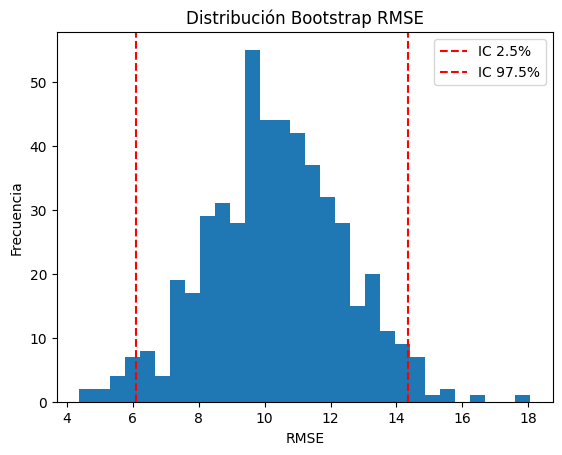

In [20]:
#5: INTERVALOS DE CONFIANZA PARA EL MEJOR MODELO
#-----------------------------------------------


best_model = grid_lasso.best_estimator_

n_boot = 500
rmse_list = []
mae_list = []
r2_list = []

n = len(X_val)  # ← cambio aquí

for i in range(n_boot):
    indices = np.random.choice(range(n), size=n, replace=True)
    
    X_sample = X_val.iloc[indices]   # ← cambio aquí
    y_sample = y_val.iloc[indices]   # ← cambio aquí
    
    y_pred = best_model.predict(X_sample)
    
    rmse_list.append(np.sqrt(mean_squared_error(y_sample, y_pred)))
    mae_list.append(mean_absolute_error(y_sample, y_pred))
    r2_list.append(r2_score(y_sample, y_pred))

rmse_ci = np.percentile(rmse_list, [2.5, 97.5])
mae_ci = np.percentile(mae_list, [2.5, 97.5])
r2_ci = np.percentile(r2_list, [2.5, 97.5])

print("IC 95% RMSE:", rmse_ci)
print("IC 95% MAE:", mae_ci)
print("IC 95% R2:", r2_ci)

plt.figure()
plt.hist(rmse_list, bins=30)
plt.axvline(rmse_ci[0], color='red', linestyle='--', label='IC 2.5%')
plt.axvline(rmse_ci[1], color='red', linestyle='--', label='IC 97.5%')
plt.title("Distribución Bootstrap RMSE")
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


In [ ]:
#PASAR A HTML

!jupyter nbconvert --to html Laboratorio2.ipynb

[NbConvertApp] Converting notebook Laboratorio2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 386266 bytes to Laboratorio2.html
